# 人脸伪造检测

## 1. 在项目开始前       

代码支持的MindSpore运行版本为 2.0.0。


在执行后文代码之前，导入运行必要库以及参数值的预设。

In [2]:
# 库的导入以及参数的预置

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # mpimg 用于读取图片
import random
import mindspore
from mindspore import nn
from mindspore import Tensor
import mindspore.dataset as ds
from mindspore import dtype as mstype
import mindspore.dataset.vision as CV
import mindspore.dataset.transforms as C


batch_size_train = 16  # 训练集划分为batch的大小
batch_size_test = 1  # 测试集划分为batch的大小
repeat = 1  # 训练集加载时，图像重复的次数
learning_rate = 1e-2  # 模型训练学习率
epoch = 20  # 训练集的训练轮次

seed = 1234
random.seed(seed)
np.random.seed(seed)
mindspore.set_seed(seed)

path_train_set = "/home/jovyan/work/datasets/6892fb249e78856c69427a9c-momodel/faceDataset/train_set"
path_test_set = "/home/jovyan/work/datasets/6892fb249e78856c69427a9c-momodel/faceDataset/test_set"
Reset = False  # 是否重置模型参数
PATH = '/home/jovyan/work/results/parameter_c.ckpt'  # 参数的目录

Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 801 ('font.family: sans-serif')
Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 802 ('font.sans-serif: SimHei')


### 1.1 项目背景
近年来，随着人工智能技术的发展，尤其是 GAN 网络、Transformer 等新一代网络模型的兴起，deepfake 等技术的出现，智能化的图像生成、编辑、修复等工具逐渐流行。  
得益于网络模型强大的学习和表征能力，通过网络模型生成/编辑/修复得到的图像在视觉上取得了很好的效果，达到了以假乱真的地步。  
然而，这类新型的图像生成/编辑/修复工具在方便人们的同时，也存在潜在的安全问题。比如网络上充斥着的 AI 换脸，如果被不法分子所利用，很有可能成为诈骗、勒索等违法犯罪行为的帮凶。  
因此，本项目旨在利用深度学习技术，检测视频中的存在的人脸伪造现象，达到判断虚假信息的目的，为维护“清洁”的互联网环境提供一定的技术支撑。

## 2. 构建数据集
1. 本次实验的数据集是有关人脸区域的真实与伪造图像数据集，其中人脸图像通过使用cv2库从视频中提取帧，并从中截取面部区域得到。           
2. 数据集一共分为两个部分：训练集与测试集。每个部分又分为`real`和`fake`两个目录，分别包含真实图像与伪造图像。     
    + 其中，为了使模型能够学习到真实图象与伪造图像的区别，训练集需要有较高的质量与较大的数量，因此选取 FF++ 和 Celeb-DF v2 两个在业界较为权威的数据集，综合两个数据集。  
      随机选取合成前的源视频以及使用人脸伪造技术合成的视频，一共产生了 2000 余张真实图象与 2000 余张伪造图像。  
      其中伪造的图像综合了当前较为著名且合成效果最强的 Deepfakes、Face2Face、FaceSwap、NeuralTextures 四种伪造方式。      
    + 而测试集主要用于检验模型与训练集的性能，因此真实视频从 YouTube 平台获取，使用人工筛选的方式保证源视频的质量，获取了 1000 余张真实图象。  
      而伪造视频则依然选 FF++ 中的融合四种伪造方式的视频，获取了 600 张伪造图像。    
3. 下文主要介绍测试集的产生过程，在测试集中：       
    + 真实视频从 YouTube 平台获取，共 40 个长度均在 1min 左右的访谈、脱口秀类视频，内容涵盖各年龄段、各人种、各领域、各时期。其中人物的肤色、神态、头部的胡须以及配饰等不尽相同。  
      40 个视频均经过认真筛选，保证其内容大多为一到二人的脸部特写，无关镜头较少，虽然有些视频清晰度较差，但是很容易从中识别出人物的面部轮廓以及面部细节信息。     
    + 伪造视频使用了人脸伪造检测领域的 FF++ 数据集，该数据集中针对每种伪造方式都生成了 1000 个伪造视频，本次的项目从中平均且随机地提取各个种类的伪造视频各几十个，作为伪造图像的源视频。   
    + 产生测试集的文件目录：      
        ```     
        │ main.py # 代码文件            
        │ real_video # 真实视频文件夹       
        │ fake_video # 伪造视频文件夹       
        │ real # 真实图象       
        │ fake # 伪造图像       
        ```
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106150832.png" width="800px"/></div>
</div>

In [3]:
# 数据集产生相关函数

def get_images(paths, second, imgs_per_video=4, new_w=224, new_h=224):  # 从视频路径paths中选取人脸图像
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    images = []
    for path in paths:
        video = cv2.VideoCapture(path)  # 捕获视频
        img_idx = [random.randint(0, 24 * second) for i in range(imgs_per_video)]  # 随机选取视频帧
        for idx in img_idx:
            video.set(cv2.CAP_PROP_POS_FRAMES, idx)  # 设定视频帧
            ret, frame = video.read()
            if ret:
                face_boundingbox = face_cascade.detectMultiScale(frame, scaleFactor=1.2, minNeighbors=15,
                                                                 minSize=(80, 80))  # 裁剪人脸区域
                for (x, y, w, h) in face_boundingbox:
                    face = frame[y:y + h, x:x + w]
                    img = cv2.resize(face, (new_w, new_h), interpolation=cv2.INTER_AREA)
                    images.append(img)
    return images

def store_image(address, images):  #将产生的图片存储在本地
    root = address.split("_")[0]
    suffix = root.split("/")[1]
    index = 0
    for img in images:
        path = root + '/' + suffix + '_' + str(index) + ".png"  # 图片目录与扩展名
        index += 1
        cv2.imwrite(path, img)

def sample_image_from_video(address, second, numFrame): # 参数为视频文件地址、视频平均长度、每个视频截取的帧数
    path = []
    result = []
    for dirpath, dirname, file in os.walk(address):  # 获取目录下的视频文件路径
        path.append(file)
    path = path[0]
    length = len(path)
    idx = random.sample(range(0, length), length)
    for i in range(0, length):
        result.append(os.path.join(address, path[idx[i]]))
    print(result)
    images = get_images(result, second, numFrame)
    store_image(address, images)


+ 运行产生图像数据      

        path_real = "./real_video"      
        path_synth = "./fake_video"         
        sample_image_from_video(path_real, 60, 30)        
        sample_image_from_video(path_synth, 9, 5) 

+ 图象数据生成之后，再通过人工筛选的方式，剔除掉完全重复的以及非人脸的数据，进一步提高生成数据集的数据质量。    
+ 生成的数据集已挂载在项目中，无需重新生成数据集。  

In [4]:
# 读取挂载的数据集，并且输出前五张图像

def load_dataset(path):
    files = []
    for dirpath, dirname, file in os.walk(path):  # 获取目录下的视频文件路径
        files.append(file)
    files = files[0]
    suffix = path.split('/')[3]
    print(suffix + "图像一共有：" + str(len(files)) + "张")
    for i in range(0, 5):
        plt.subplot(1, 5, i + 1)
        plt.axis('off')  # 不显示坐标轴
        img = mpimg.imread(path + '/' + files[i])
        plt.imshow(img)
    plt.show()

在训练集中：
work图像一共有：2161张


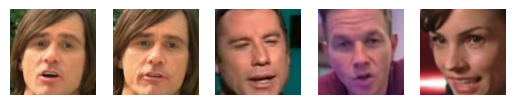

work图像一共有：2065张


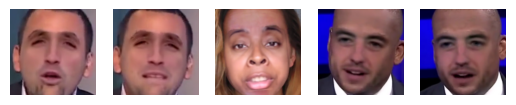

In [5]:
print("在训练集中：")
path_real = path_train_set + '/real'
path_synth = path_train_set + '/fake'
load_dataset(path_real)
load_dataset(path_synth)

在测试集中：
work图像一共有：1032张


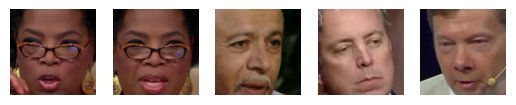

work图像一共有：600张


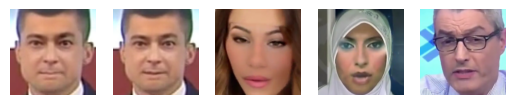

In [6]:
print("在测试集中：")
path_real = path_test_set + '/real'
path_synth = path_test_set + '/fake'
load_dataset(path_real)
load_dataset(path_synth)


## 3. 数据集分析与可视化
在上一个部分的最后，我们通过调用 matplotlib.pyplot 库，对数据集的图像数量及内容进行了简单的可视化。
      
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106152028.png" width="800px"/></div>
</div>      

但是上文中加载的数据集无法实际用于训练，因此在这一部分，我们将主要面向之后的模型训练，将这些图像数据加载并处理成为可以输入网络模型进行训练或测试数据集，并在该过程中对数据集的细节内容进行分析展示。     
1. `create_dataset`函数根据数据集文件目录进行数据集的创建，并随机打乱图像。     
2. `dataset_transform`函数进行图像数据的转换(其中包括 resize, normalize 等操作)，并在转换完成后，为数据增加标签 label ，并划分为 image 和 label 两列。         
3. `create_batch`函数将数据集划分为训练用的 batch，并根据训练时的实际要求进行 repeat 操作。        
     

In [7]:
# 数据集加载与转换相关函数

def create_dataset(path):  # 创建数据集并返回总图像数
    dataset = ds.ImageFolderDataset(path, shuffle=True)
    num_imgs = dataset.get_dataset_size()
    print("数据集大小为：" + str(num_imgs))
    return dataset


def dataset_transform(dataset, side_length=224):  # 图像的变换
    image_size = [side_length, side_length]
    mean = [127.5, 127.5, 127.5]
    std = [255., 255., 255.]
    trans = [
        CV.Decode(),
        CV.Resize(image_size),
        CV.Normalize(mean=mean, std=std),
        CV.HWC2CHW()
    ]
    type_cast_op = C.TypeCast(mstype.int32)
    # 实现数据的map映射、批量处理和数据重复的操作
    dataset = dataset.map(operations=trans, input_columns="image", num_parallel_workers=8)
    dataset = dataset.map(operations=type_cast_op, input_columns="label", num_parallel_workers=8)
    print("数据集一共分为" + str(dataset.num_classes()) + "列，分别为：" + str(dataset.get_col_names()))
    print("标签与类别的对应关系为：" + str(dataset.get_class_indexing()))
    return dataset


def create_batch(dataset, batch_size, repeat=1):  # 图像划分批次
    batch_set = dataset.batch(batch_size, drop_remainder=True)
    num_bt = batch_set.get_dataset_size()
    batch_set = batch_set.repeat(repeat)
    print("数据集划分为的batch数为：" + str(num_bt))
    return batch_set


&nbsp;     
利用上文中提供的函数与文件路径，我们加载并按序分别创建、处理训练集与测试集，并在过程中输出数据集的基本信息，其中包括：      
* 数据集大小       
* 数据集的分列情况    
* 数据的分类以及类别与标签的对应情况       
* 数据集划分为的用于训练的批次数       
&nbsp;     

In [8]:
print("训练集：")
train_set = create_dataset(path_train_set)
train_set = dataset_transform(train_set)
train_set = create_batch(train_set, batch_size_train, repeat)


训练集：
数据集大小为：4226
数据集一共分为2列，分别为：['image', 'label']
标签与类别的对应关系为：{'fake': 0, 'real': 1}
数据集划分为的batch数为：264


In [9]:
print("测试集：")
test_set = create_dataset(path_test_set)
test_set = dataset_transform(test_set)
test_set = create_batch(test_set, batch_size_test, 1)

测试集：
数据集大小为：1632
数据集一共分为2列，分别为：['image', 'label']
标签与类别的对应关系为：{'fake': 0, 'real': 1}
数据集划分为的batch数为：1632


In [10]:
# 展示训练集前三个输入batch的基本情况

for i in range(3):
    data = next(train_set.create_dict_iterator())
    print(data['label'])  # 标签中1对应real，0对应fake
    print(data['image'].shape)
    

[0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1]
(16, 3, 224, 224)
[0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1]
(16, 3, 224, 224)
[0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1]
(16, 3, 224, 224)


## 4. 模型搭建
1. 近年来 EfficientNet 在特征提取中取得了较好的效果，因此本项目使用该网络架构用于此次人脸伪造检测。
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106152237.png" width="600px"/></div>
</div>      
2. 根据上图可知，该网络结构主要由 Conv，MBConv，Pooling，FC 几个模块构成，其中除了 MBConv 模块以外，其他的通用模块都在 mindspore 框架中已有实现，因此主要需要编程实现的是 MBConv 模块。       
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106152311.png" width="600px"/></div>
</div>      
3. 而在 MBVConv 模块中，需要重点实现 Depthwise Conv 和 SE 模块。     
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106152346.png" width="400px"/></div>
</div>      
4. 根据上图对于各模块的详细描述，同时参考 EfficientNet v0 关于上述各模块的具体参数（包括 Dropout 模块），使用 mindspore 实现搭建模型：            

In [11]:
# 网络模型Network及具体模块SE、MBConv的具体实现

class SE(nn.Cell):  # SE注意力模块
    def __init__(self, channel_in, channel_mid):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.liner1 = nn.SequentialCell(
            nn.Dense(channel_in, channel_mid),
            nn.HSwish()
        )
        self.liner2 = nn.SequentialCell(
            nn.Dense(channel_mid, channel_in),
            nn.Sigmoid()
        )

    def construct(self, x):
        result = self.pool(x)
        result = result.squeeze(-1)
        result = result.squeeze(-1)

        result = self.liner1(result)
        result = self.liner2(result)

        result = result.unsqueeze(2)
        result = result.unsqueeze(3)
        result = x * result
        return result


class MBConv(nn.Cell):
    def __init__(self, channel_in, times, channel_out, kernel_size, stride):
        super().__init__()

        self.channel_in = channel_in
        self.channel_out = channel_out
        self.kernel_size = kernel_size
        self.stride = stride
        self.channel_mid = channel_in * times
        self.Conv1 = nn.SequentialCell(
            nn.Conv2d(channel_in, self.channel_mid, 1, 1),
            nn.BatchNorm2d(self.channel_mid),
            nn.HSwish()
        )
        self.DConv = nn.SequentialCell(
            nn.Conv2d(self.channel_mid, self.channel_mid, kernel_size, stride, 'same', 0, 1, self.channel_mid),
            nn.BatchNorm2d(self.channel_mid),
            nn.HSwish()
        )
        self.SE = SE(self.channel_mid, int(self.channel_in / 4))
        self.Conv2 = nn.SequentialCell(
            nn.Conv2d(self.channel_mid, self.channel_out, 1, 1),
            nn.BatchNorm2d(self.channel_out)
        )
        self.Drop = nn.Dropout(p=0.25)

    def construct(self, x):
        output = x
        if self.channel_in != self.channel_mid:
            output = self.Conv1(x)
        output = self.DConv(output)
        output = self.SE(output)
        output = self.Conv2(output)
        output = self.Drop(output)
        if output.shape == x.shape:
            output = output + x
        return output


    
5. 最后，将实现了的各个模块按照一定顺序，组合成为网络模型 Network。

In [12]:
# 网络模型结构

class Network(nn.Cell):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, 2)

        self.mbc1 = MBConv(32, 1, 16, 3, 1)
        self.mbc2 = MBConv(16, 6, 24, 3, 2)
        self.mbc3 = MBConv(24, 6, 40, 5, 2)
        self.mbc4 = MBConv(40, 6, 80, 3, 2)

        self.pool = nn.AvgPool2d(2)

        self.liner = nn.SequentialCell(
            nn.Dense(13520, 2048),
            nn.LeakyReLU(),
            nn.Dense(2048, 512),
            nn.LeakyReLU(),
            nn.Dense(512, 32),
            nn.LeakyReLU(),
            nn.Dense(32, 2),
        )

    def construct(self, x, batch_size):
        x = self.conv1(x)

        result = self.mbc1(x)
        result = self.mbc2(result)
        result = self.mbc3(result)
        result = self.mbc4(result)
        result = self.pool(result)
        result = result.reshape((batch_size, -1))
        result = self.liner(result)
        return result



## 5. 模型训练         
1. 首先要将从文件中加载的数据集进行适当的加工，使其满足模型的输入要求，这一步在数据集分析与可视化部分已经完成。       
2. 预处理完成之后，进行模型的加载及训练相关参数的定义：     
	+ 实例化 network 对象，并在需要时加载保存好的模型参数。      
	+ 定义模型训练时的损失函数、优化器、梯度更新方式以及训练步骤。		       

In [13]:
# 训练过程与参数的定义
# 初始化模型
network = Network()

loss = nn.CrossEntropyLoss()
optimizer = nn.Adam(network.trainable_params(), learning_rate)
network.set_train()


def forward(data, label):
    predict = network(data, batch_size_train)
    result = loss(predict, label)
    return result, predict


gradient = mindspore.value_and_grad(forward, None, optimizer.parameters, has_aux=True)


def train_step(data, label):
    (loss, _), grads = gradient(data, label)
    optimizer(grads)
    return _, loss

3. 接下来，进行训练与测试过程细节的定义，为之后的训练、测试、评估过程都做好准备：
    + 训练前扩展 label 数据的维度，满足模型输入要求      
    + 训练过程中每隔一定批次输出训练损失，观察拟合情况       
    + 记录训练损失随批次变化情况，输出为折线图     
    + 根据损失变化情况，在训练过程中自动更新学习率 learning rate       
    + 每隔一定批次输出模型关于测试集的损失，预防过拟合       
    + 每轮训练完成后检查模型关于测试集的正确率，检验模型性能     
       

In [14]:
# 训练与测试过程细节的定义

def expand_label(label):  # 扩展label数据的维度 
    labels = np.zeros((batch_size_train, 2)).astype(np.float32)
    for i in range(0, batch_size_train):  # 标签为0则第0维的值更大，便于之后测试进行argmax相对应
        if abs(label[i] - 0.0) < 0.01:
            labels[i][0] = 1.0
        elif abs(label[i] - 1.0) < 0.01:
            labels[i][1] = 1.0
    labels = Tensor(labels)
    return labels


def show_loss(loss_list):  # 将损失变化输出为折线图 
    plt.figure()
    plt.plot(loss_list, 'b', label='Recon_loss')
    plt.ylabel('Recon_loss')
    plt.xlabel('iter_num')
    plt.legend()
    plt.savefig("/home/jovyan/work/results/1_recon_loss.jpg")

def train():
    global learning_rate
    running_loss = 0  # 记录连续批次的损失和
    loss_list = []  # 损失变化情况
    store_dis = 0  # 记录损失和的差
    store_loss = running_loss  # 存储上一轮损失和
    for i in range(epoch):
        print("epoch:" + str(i))
        for batch, (data, label) in enumerate(train_set.create_tuple_iterator()):
            label = expand_label(label)
            predict, result = train_step(data, label)
            loss_list.append(result)
            running_loss += result

            if batch % 10 == 0:
                print("the train loss is: %.4f" % (running_loss / 10))
                mindspore.save_checkpoint(network, PATH)
                if abs(store_loss - running_loss) < store_dis and learning_rate > 0.00001:  # 更新学习率
                    learning_rate *= 0.8
                store_dis = abs(store_loss - running_loss)
                store_loss = running_loss
                running_loss = 0
            
            if batch % 40 == 0:  # 输出测试集损失
                test_loss()

            if batch % 100 == 0:  # 输出损失变化图
                print(learning_rate)
                show_loss(loss_list)
                loss_list = []

        test()
    print("训练结束！")


def test_loss(): # 输出测试集损失
    running_loss = 0
    for batch, (data, label) in enumerate(test_set.create_tuple_iterator()):
        loss, predict = forward(data, label)
        running_loss += loss
        if batch % 1000 == 19:
            print("the test loss is: %.4f" % (running_loss / 20))
            return


def test():
    sum_test = 0
    num = 0
    for batch, (data, label) in enumerate(test_set.create_tuple_iterator()):
        sum_test += batch_size_test
        predict = network(data, batch_size_test)
        predict = predict.argmax(1)
        for i in range(len(label)):
            if int(label[i]) == predict[i]:
                num += 1

    current = num / sum_test
    print("the current rate is: %.2f %%" % (current * 100))


4. 准备工作结束，正式进行训练与测试（实际的模型训练通过使用平台提供的 GPU，运行`train.py`）       
    + `train()` 执行训练过程      
    + `test()` 执行一次整个测试集上的测试      
5. 训练完成后，加载保存好的模型参数，利用之前加载好的测试集数据，在 notebook 中加载模型进行推理，并展示推理结果。     


In [15]:
# 任意选取五张图片，观察其预测标签与真实标签是否一致

network = Network()
best_param = '/home/jovyan/work/results/parameter_c.ckpt'
param_dict = mindspore.load_checkpoint(best_param)
mindspore.load_param_into_net(network, param_dict)
print("模型参数加载完毕")

test_iterator = test_set.create_dict_iterator()

for i in range(5):
    data = next(test_iterator)
    predict = network(data['image'], batch_size_test)
    print("模型的输出结果为：" + str(predict))
    predict = predict.argmax(1)
    print("模型的预测标签为：" + str(predict[0]))
    print("该图像的实际标签是：" + str(data['label'][0]))  # 标签中1对应real，0对应fake

模型参数加载完毕
模型的输出结果为：[[-0.02908896 -0.00479997]]
模型的预测标签为：1
该图像的实际标签是：0
模型的输出结果为：[[-0.08126234 -0.03340835]]
模型的预测标签为：1
该图像的实际标签是：0
模型的输出结果为：[[-0.1547499 -0.1012824]]
模型的预测标签为：1
该图像的实际标签是：1
模型的输出结果为：[[-0.22233428 -0.17178376]]
模型的预测标签为：1
该图像的实际标签是：1
模型的输出结果为：[[-0.461441  -0.2613846]]
模型的预测标签为：1
该图像的实际标签是：1



## 6. 模型评估
模型的评估分为两个部分：训练过程中的评估与训练完成后的评估
1. 训练过程中的评估，评估模型的拟合能力，并在过程中微调超参数，寻找合适的模型结构等等，评估的标准是损失的值与变化情况，其中在训练中主要关注的是：              
    
    > 训练损失值以及下降速度       
    > 训练损失的震荡      
    > 训练损失与测试损失的比较       
    
具体在模型的训练过程中：        
+ 模型在实际训练过程中的某次训练的损失变化记录，通过观察可知模型随着训练不断收敛，但是收敛的速度较慢，由此考虑适当增大 batch_size, 与 learning_rate 参数，提高收敛速度，同时增大 epoch 保证模型充分收敛。

+ 如下图展示的则是模型结构在训练的过程中损失的变化情况： 
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106180926.png" width="400px"/></div>
</div>      

可见损失的震荡现象非常明显，因此考虑增大 batch_size，并在训练的过程中随着轮次增加适当减少 learning_rate，经过一番修改之后，损失的变化情况如下图，可见震荡情况已经得到了有效的缓解，但是依然存在损失突然急剧增大的少数情况。          
     
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/20231106180955.png" width="400px"/></div>
</div>      


+ 接下来展示的则是模型训练过程中 train_loss 与 test_loss 同步的变化情况。  
可以看出随着训练损失逐渐减少的过程中，测试损失没有明显下降趋势甚至有上升的情况。  
可以考虑模型此时已经严重过拟合，导致两类损失没有同步下降。因此如此过拟合的模型权重应该被舍弃，模型也应当调整好 epoch 参数重新进行训练。

      

2. 训练完成后的评估，分别使用训练集和测试集评估模型的性能，评估的指标主要有：         
    > 准确率 Accuracy         
    > 精确率 Precision          
    > 召回率 Recall(TPR)          
    > 假阳率 FPR          

其中：由于该任务的目标是人脸伪造的检测，因此应当更关注模型正确识别伪造图像的能力，应当将 TPR 和 FPR 作为最关键的评价指标。  
因此使用下文中的函数对于模块性能进行评估。   

在测试集上测试结果如下:  
测试集数量为 1632  
the accuracy rate is: 58.2 %  
the precision rate is: 43.1 %  
the recall rate(TPR) is: 42.8 %  
the FPR is: 32.8 %  

经过分析可知:       
+ 首先是模型的 accuracy 不高，    
+ 其次是 precision 和 recall 都远低于 accuracy      
+ 最后 FPR 也不够低       

因此，由于模型在训练集上的正确率很高。  
可见模型提取的特征区分度不足，且泛化能力不足，需要改进模型结构。           

In [16]:
# 训练后模型评估相关函数
# 由于notebook端的运行速度较慢，该评估程序具体实现在evaluate.py中，并且使用官方GPU运行

def test_evaluate():  # 评估模型的准确率
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for batch, (data, label) in enumerate(test_set.create_tuple_iterator()):
        predict = network(data, batch_size_test)
        predict = predict.argmax(1)
        for i in range(len(label)):
            if predict[i] == 0: # 0对应fake对应阳性
                if int(label[i]) == 0:
                    TP += 1
                else:
                    FP += 1
            elif predict[i] == 1:
                if int(label[i]) == 1:
                    TN += 1
                else:
                    FN += 1
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)  # TPR
    FPR = FP / (TN + FP)
    print("the accuracy rate is: %.1f %%" % (accuracy * 100))
    print("the precision rate is: %.1f %%" % (precision * 100))
    print("the recall rate(TPR) is: %.1f %%" % (recall * 100))
    print("the FPR is: %.1f %%" % (FPR * 100))

综上，经过训练过程中的模型评估，对模型进行了一定程度的优化。经过训练后的评估，也对模型的性能有了更加充分的了解。  
通过评估，对当前的模型总结到以下结论以及未来的改进方式：           


|  评估结果   | 改进方案  |
|  ----  | ----  |
| 模型收敛速度较慢  | 1. 在内存支持的情况下适当增加 batch_size 和 learning_rate 参数 <br>  2. 保证训练轮次 epoch 足够 |
| 训练损失震荡未消除  | 均衡调整增加 batch_size 并随训练逐步减小 learning_rate |
| 模型训练后期过拟合  | 密切关注 test_loss 变化情况，控制训练轮次 epoch |
| 模型性能欠佳  | 1. 适当增加模型复杂度，优化网络结构，有效提取特征  <br>  2. 提高数据集质量 |